# Breadth-First Search (BFS)

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement BFS; trace exploration order
- Use BFS for shortest paths in unweighted graphs

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 04 "Intelligent Agents and Rationality" — a goal-based agent needs a way to *find* the goal; search is that way.

**Used later in:** Course 02 (AIAT 112) — Unit 1, which re-implements BFS with full theory, complexity analysis and side-by-side visualisation.

---


## 🎯 3.57 degrees, measured on 1.59 billion people

In February 2016 Facebook's research team published the result of a shortest-path
computation over its whole social graph: **1.59 billion active accounts**, with an
average separation between any two people of **3.57 degrees** — down from 3.74
when they had measured 721 million users in 2011. "Six degrees of separation" had
been a famous guess since Milgram's 1967 letter experiment; this was the first
time anyone ran the calculation at planetary scale.

The question they answered — *what is the fewest hops between these two nodes?* —
is exactly the question BFS answers, and it is the only question BFS answers.
Note also what the scale forced them to do: an exact BFS from every one of 1.59
billion starting points is not affordable, so they used statistical estimators
instead. Keep that in mind for the limits section at the end of this notebook.

### What goes wrong without BFS

Suppose you search for a route by always following the first neighbour you see
until you hit the goal. You will find *a* path — and you will have no idea
whether it is twice as long as necessary. That is not a hypothetical: the next
notebook (DFS) does exactly that on this same graph and returns
`A → B → E → F` where BFS returns `A → C → F`. BFS is the algorithm that lets
you say the word **shortest** and mean it.


# Breadth-First Search (BFS)

## 📚 Learning Objectives

This notebook demonstrates key concepts through hands-on examples.

By completing this notebook, you will:
- Understand the core concepts
- See practical implementations
- Be ready for exercises

---

## Code Example

Run the code below to see the demonstration:


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

Example 1: Breadth-First Search (BFS)

Testing BFS Algorithm

Searching for path from A to F...
  Visiting: A, Path: A
  Visiting: B, Path: A -> B
  Visiting: C, Path: A -> C
  Visiting: D, Path: A -> B -> D
  Visiting: E, Path: A -> B -> E
  Visiting: F, Path: A -> C -> F

✓ Goal found! Path: A -> C -> F

Result: ['A', 'C', 'F']

------------------------------------------------------------

Searching for path from D to C...
  Visiting: D, Path: D
  Visiting: B, Path: D -> B
  Visiting: A, Path: D -> B -> A
  Visiting: E, Path: D -> B -> E
  Visiting: C, Path: D -> B -> A -> C

✓ Goal found! Path: D -> B -> A -> C

Result: ['D', 'B', 'A', 'C']

Example completed successfully!


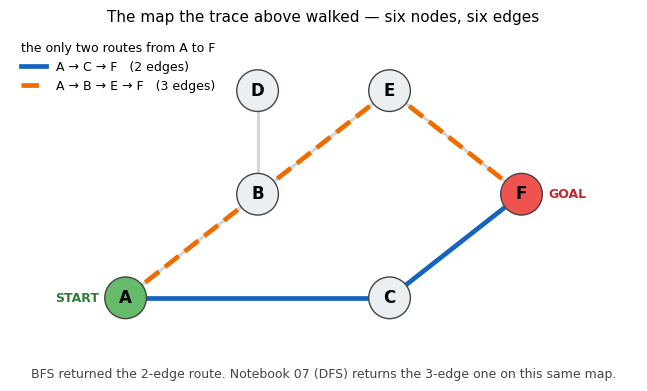


Routes from A to F found by enumeration: A → C → F (2 edges) | A → B → E → F (3 edges)


In [1]:
"""
Unit 1 - Example 06: Breadth-First Search (BFS)

This example demonstrates:
1. BFS algorithm implementation
2. Finding shortest path in a graph
3. Visualizing the search process
"""

from collections import deque

print("=" * 60)
print("Example 1: Breadth-First Search (BFS)")
print("=" * 60)

# Graph representation
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

def bfs(graph, start, goal):
    """
    Breadth-First Search algorithm.
    
    Args:
        graph: Dictionary representing the graph
        start: Starting node
        goal: Target node
    
    Returns:
        Path from start to goal, or None if not found
    """
    # Queue for BFS
    queue = deque([(start, [start])])
    visited = set([start])
    
    print(f"\nSearching for path from {start} to {goal}...")
    
    while queue:
        current, path = queue.popleft()
        
        print(f"  Visiting: {current}, Path: {' -> '.join(path)}")
        
        if current == goal:
            print(f"\n✓ Goal found! Path: {' -> '.join(path)}")
            return path
        
        # Explore neighbors
        for neighbor in graph.get(current, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    
    print(f"\n✗ No path found from {start} to {goal}")
    return None

# Test BFS
print("\n" + "=" * 60)
print("Testing BFS Algorithm")
print("=" * 60)

# Test case 1
path1 = bfs(graph, 'A', 'F')
print(f"\nResult: {path1}")

# Test case 2
print("\n" + "-" * 60)
path2 = bfs(graph, 'D', 'C')
print(f"\nResult: {path2}")

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)

# ── The map, drawn ONCE, with the only two routes from A to F ────────────────
# WHAT: one picture of the same six-node graph the trace above walked, on the FIXED
#       coordinates notebooks 06, 07 and 08 all share, with every A→F route traced.
# WHY : the printed trace is a list of node names. The question the three search
#       notebooks differ on is "which route comes back?" — and you cannot ask that
#       until you can see that there are exactly two of them.
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

POS = {'A': (0, 0), 'B': (1, 1), 'C': (2, 0), 'D': (1, 2), 'E': (2, 2), 'F': (3, 1)}
G_map = nx.Graph()
for _node, _nbrs in graph.items():
    for _nbr in _nbrs:
        G_map.add_edge(_node, _nbr)

# Enumerated, not guessed: ask networkx for every simple path and sort by length.
routes = sorted(nx.all_simple_paths(G_map, 'A', 'F'), key=len)

fig_map, ax_map = plt.subplots(figsize=(7.0, 4.0))
nx.draw_networkx_edges(G_map, POS, ax=ax_map, edge_color='#d5d5d5', width=2.2)
handles = []
for _route, (_col, _style) in zip(routes, [('#1565c0', 'solid'), ('#ef6c00', 'dashed')]):
    nx.draw_networkx_edges(G_map, POS, edgelist=list(zip(_route, _route[1:])), ax=ax_map,
                           edge_color=_col, width=3.4, style=_style)
    handles.append(Line2D([], [], color=_col, lw=3.4, linestyle=_style,
                          label=f"{' → '.join(_route)}   ({len(_route) - 1} edges)"))
_colours = ['#66bb6a' if n == 'A' else '#ef5350' if n == 'F' else '#eceff1'
            for n in G_map.nodes()]
nx.draw_networkx_nodes(G_map, POS, ax=ax_map, node_color=_colours,
                       edgecolors='#444444', node_size=900)
nx.draw_networkx_labels(G_map, POS, ax=ax_map, font_size=12, font_weight='bold')
ax_map.text(POS['A'][0] - 0.20, POS['A'][1], "START", fontsize=9, color='#2e7d32',
            va='center', ha='right', fontweight='bold')
ax_map.text(POS['F'][0] + 0.20, POS['F'][1], "GOAL", fontsize=9, color='#c62828',
            va='center', ha='left', fontweight='bold')
ax_map.legend(handles=handles, loc='upper left', fontsize=9, frameon=False,
              title="the only two routes from A to F", title_fontsize=9)
ax_map.set_title("The map the trace above walked — six nodes, six edges", fontsize=11)
ax_map.text(0.5, -0.06, "BFS returned the 2-edge route. Notebook 07 (DFS) returns the 3-edge one on this same map.", transform=ax_map.transAxes, ha='center',
            fontsize=9, color='#444444')
ax_map.set_axis_off()
ax_map.margins(0.22)
fig_map.tight_layout()
plt.show()

print(f"\nRoutes from A to F found by enumeration: "
      f"{' | '.join(' → '.join(r) + f' ({len(r) - 1} edges)' for r in routes)}")


### 👁️ Read the map

**One map, drawn once, and every later picture in notebooks 06–08 uses these exact
node positions** — so nothing you see later can contradict it.

Six nodes, six edges. `A` is green and marked START, `F` is red and marked GOAL.
`networkx` enumerated the routes rather than us guessing them, and there are
exactly **two**: the solid blue `A → C → F` (2 edges) and the dashed orange
`A → B → E → F` (3 edges). `D` hangs off `B` and leads nowhere near `F` — it is
the dead end that costs BFS an expansion.

That is the whole question this unit turns on: **which of these two routes does a
search return, and how much work does it do to get there?** BFS returned the
2-edge one in the trace above. Watch the storyboard below to see the price it paid.


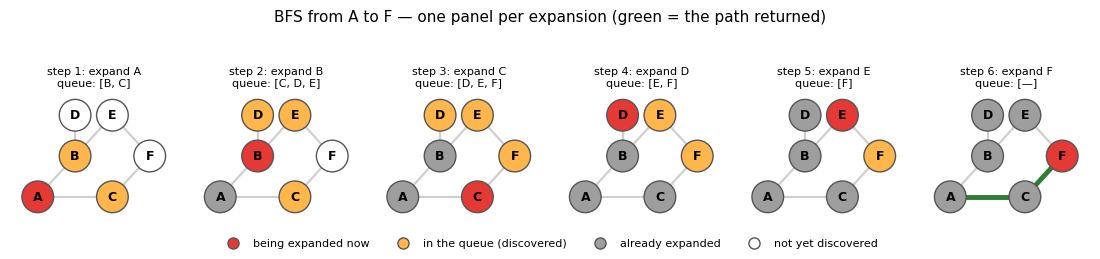

step  expand  queue after        visited              path so far
   1    A     [B, C]             {A, B, C}            A
   2    B     [C, D, E]          {A, B, C, D, E}      A -> B
   3    C     [D, E, F]          {A, B, C, D, E, F}   A -> C
   4    D     [E, F]             {A, B, C, D, E, F}   A -> B -> D
   5    E     [F]                {A, B, C, D, E, F}   A -> B -> E
   6    F     []                 {A, B, C, D, E, F}   A -> C -> F


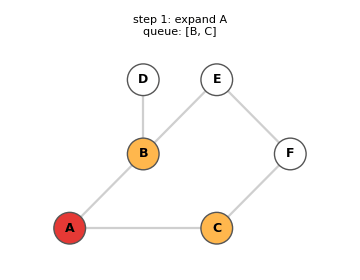


Animated GIF above: 6 frames, 24 KB


In [2]:
# ── Storyboard: watch the BFS frontier grow, one expansion at a time ───────────
# WHAT: replay the EXACT run printed above (A -> F), recording the queue and the visited
#       set at every expansion, then draw one panel per step and an animated GIF of them.
# WHY:  the printed trace is a list of lines, and "level by level" is a *shape*. You only
#       see a shape by looking at it — here, a frontier spreading outward ring by ring.
import io
from collections import deque

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.lines import Line2D

# Fixed node coordinates — identical in notebooks 06, 07 and 08 — so the three
# storyboards can be placed side by side and compared panel for panel.
POS = {'A': (0, 0), 'B': (1, 1), 'C': (2, 0), 'D': (1, 2), 'E': (2, 2), 'F': (3, 1)}

G = nx.Graph()
for node, neighbours in graph.items():
    for neighbour in neighbours:
        G.add_edge(node, neighbour)


def bfs_trace(g, start, goal):
    """Same algorithm as bfs() above — it RECORDS the state instead of printing it."""
    queue = deque([(start, [start])])
    visited = {start}
    steps = []
    while queue:
        current, path = queue.popleft()
        if current != goal:                       # the goal test happens before expanding
            for neighbour in g.get(current, []):
                if neighbour not in visited:
                    visited.add(neighbour)
                    queue.append((neighbour, path + [neighbour]))
        steps.append({'current': current, 'path': path,
                      'queue': [n for n, _ in queue], 'visited': set(visited)})
        if current == goal:
            break
    return steps


steps = bfs_trace(graph, 'A', 'F')

# Honesty check: the storyboard must show the same run the cell above printed.
assert [s['current'] for s in steps] == ['A', 'B', 'C', 'D', 'E', 'F'], "visit order changed"
assert steps[-1]['path'] == path1, "path changed"


def draw_step(ax, s, k, done):
    """Colour every node by its role at step k: expanding / queued / done / unseen."""
    expanded = [st['current'] for st in steps[:k]]
    colours = []
    for n in G.nodes():
        if n == s['current']:
            colours.append('#e53935')          # red   = being expanded right now
        elif n in expanded:
            colours.append('#9e9e9e')          # grey  = already expanded
        elif n in s['queue']:
            colours.append('#ffb74d')          # amber = discovered, waiting in the queue
        else:
            colours.append('white')            # white = not discovered yet
    nx.draw_networkx_edges(G, POS, ax=ax, edge_color='#cfcfcf', width=1.6)
    nx.draw_networkx_nodes(G, POS, ax=ax, node_color=colours,
                           edgecolors='#555555', node_size=520)
    nx.draw_networkx_labels(G, POS, ax=ax, font_size=9, font_weight='bold')
    if done:                                    # last panel: the path BFS returned
        p = s['path']
        nx.draw_networkx_edges(G, POS, edgelist=list(zip(p, p[1:])), ax=ax,
                               edge_color='#2e7d32', width=3.5)
    ax.set_title(f"step {k + 1}: expand {s['current']}\nqueue: [{', '.join(s['queue']) or '—'}]",
                 fontsize=8)
    ax.set_axis_off()
    ax.margins(0.18)


n_steps = len(steps)
fig, axes = plt.subplots(1, n_steps, figsize=(1.85 * n_steps, 2.5))
for k, (ax, s) in enumerate(zip(axes, steps)):
    draw_step(ax, s, k, done=(k == n_steps - 1))
legend = [Line2D([], [], marker='o', linestyle='', markersize=8, markerfacecolor=c,
                 markeredgecolor='#555', label=l)
          for c, l in [('#e53935', 'being expanded now'), ('#ffb74d', 'in the queue (discovered)'),
                       ('#9e9e9e', 'already expanded'), ('white', 'not yet discovered')]]
fig.legend(handles=legend, loc='lower center', ncol=4, frameon=False, fontsize=8)
fig.suptitle('BFS from A to F — one panel per expansion (green = the path returned)', fontsize=11)
fig.tight_layout(rect=[0, 0.09, 1, 0.93])
plt.show()

# The same storyboard as a table you can read out loud in class.
print(f"{'step':>4}  {'expand':^6}  {'queue after':<18} {'visited':<20} path so far")
for k, s in enumerate(steps, 1):
    print(f"{k:>4}  {s['current']:^6}  {'[' + ', '.join(s['queue']) + ']':<18} "
          f"{'{' + ', '.join(sorted(s['visited'])) + '}':<20} {' -> '.join(s['path'])}")

# Animated version of the very same frames (the repo's Course 09 step-viz idiom:
# render frames -> encode a GIF -> display it). The grid above is the fallback.
try:
    from IPython.display import Image as IPyImage, display
    from PIL import Image

    frames = []
    for k, s in enumerate(steps):
        f2, ax2 = plt.subplots(figsize=(3.6, 2.8), dpi=100)
        draw_step(ax2, s, k, done=(k == n_steps - 1))
        f2.tight_layout()
        f2.canvas.draw()
        frames.append(Image.fromarray(np.asarray(f2.canvas.buffer_rgba())[:, :, :3]))
        plt.close(f2)
    buf = io.BytesIO()
    frames[0].save(buf, format='GIF', save_all=True, append_images=frames[1:],
                   duration=900, loop=0)
    display(IPyImage(data=buf.getvalue()))
    print(f"\nAnimated GIF above: {len(frames)} frames, {len(buf.getvalue()) / 1024:.0f} KB")
except Exception as exc:                        # pragma: no cover - display convenience only
    print(f"\n(GIF skipped: {exc}) — the frame grid above carries the same information.")


### 👁️ Read the storyboard

**What you are looking at:** six panels, one per expansion, on the same six-node
graph the trace above searched. Red is the node being expanded *now*, amber is a
node that has been discovered and is sitting in the queue, grey is a node already
expanded, white is a node BFS has not seen yet. The green edges in the last panel
are the path it returned.

**What the picture proves, and the printed trace does not show at a glance:**

- **The frontier moves outward in rings.** After step 1 the queue holds `[B, C]` —
  everything one hop from A. Both are expanded (steps 2 and 3) *before* anything
  two hops away. That is the whole reason BFS can say the word "shortest".
- **F is found early and expanded last.** Look at step 3: expanding C discovers F,
  and the queue becomes `[D, E, F]`. BFS still expands D and E first, because they
  were queued earlier. Six expansions for a goal that was visible after three —
  that is what optimality costs.
- **The amber nodes are the memory bill.** At step 2 there are three of them at
  once. On this toy graph that is nothing; multiply the amber count by a branching
  factor of 30 and you have the memory explosion described at the end of this notebook.

Notebooks 07 and 08 draw the same graph with the same node positions, so you can
put the three storyboards side by side: DFS uses **5** panels, A* uses **4**, BFS
uses **6** — the exact counts compared in the table below.


## 📊 The number to carry to the next two notebooks

Read the trace above carefully — it is the baseline for a three-notebook
comparison run on the **same six-node graph** with the same start and goal:

| notebook | algorithm | nodes visited to reach F | path returned | edges |
|---|---|---|---|---|
| **06 (this one)** | **BFS** | **6 (A, B, C, D, E, F)** | **A → C → F** | **2** |
| 07 | DFS | 5 (A, B, D, E, F) | A → B → E → F | 3 |
| 08 | A* | 4 (A, B, C, F) | A → C → F | 2 |

BFS paid for its guarantee: it expanded every node at distance 1 (B and C) and
then every node at distance 2 (D, E, F) before it could *prove* nothing shorter
existed. DFS visited one fewer node and returned a path 50% longer. A* visited
the fewest and still found the shortest — because it was allowed to look at the
coordinates, which BFS never sees.

**The conclusion these three runs actually support:** on an unweighted graph, BFS
buys optimality with memory, and a heuristic buys back some of the memory. It
does *not* support "A* is always better" — notebook 08 shows what the heuristic
costs you.


## 💬 Discuss

1. BFS returned `A → C → F` and DFS returned `A → B → E → F`. Both are valid
   paths. Describe a real routing problem where the DFS answer is **good enough**
   and finding the shortest path would be a waste of engineering — and one where
   the extra edge is unacceptable.
2. Facebook could not run exact BFS from 1.59 billion sources and used estimates
   instead. If your estimate says "3.57 degrees" and the truth is 3.6, does the
   headline change? Now suppose the same 1% error appears in an ambulance
   dispatcher's route. **When is an approximate shortest path acceptable, and who
   should decide?**
3. This graph treats every edge as costing 1. Take a road map of your own city
   and argue whether "fewest turns" or "fewest minutes" is the right thing to
   minimise — and what you would tell a delivery company that asked for both.


---

## ✅ Summary

Great job completing this example!

### What You Learned:

**Breadth-First Search (BFS) Algorithm:**
- **How it works**: Explores graph level-by-level, visiting all neighbors of current node before moving to next level
- **Data structure**: Uses a queue (FIFO - First In First Out) to process nodes in order of discovery
- **Guarantee**: Always finds the shortest path (in terms of number of edges) in unweighted graphs
- **Memory**: Stores all nodes at current level, so memory usage can be high for wide graphs

**Key Implementation Details:**
- **Queue**: Uses `collections.deque` for efficient queue operations
- **Visited tracking**: Uses a set to avoid revisiting nodes (prevents infinite loops)
- **Path tracking**: Maintains the path from start to current node for each exploration

**When to use BFS:**
- ✅ Finding shortest path in unweighted graphs
- ✅ Level-order traversal of trees
- ✅ Finding all nodes at a specific distance
- ⚠️ Not ideal for: Deep graphs (uses more memory), weighted graphs (use Dijkstra's instead)

### 🔗 How This Connects:

**This example builds on and leads to:**
- **Unit 1: AI Foundations** - Search algorithms are fundamental AI problem-solving techniques
- **Example 2: DFS Algorithm** - Compare BFS (level-by-level) with DFS (deep-first) to understand different search strategies
- **Example 3: A* Algorithm** - Advanced search that combines BFS concepts with heuristics for intelligent search
- **example 10 (Knowledge Representation)** - Search algorithms help navigate knowledge graphs

**📚 Related Content:**

**Why learn BFS first?**
1. **Simplest search algorithm**: Easiest to understand and implement
2. **Foundation**: Other search algorithms (DFS, A*) build on similar concepts
3. **Practical**: Used in many real-world applications (GPS, game AI, web crawling)

**Common Student Questions:**
- **Q: Why use a queue (FIFO) for BFS?**
  - Answer: Queue = First In First Out → explores nodes level by level
  - BFS explores all neighbors at current level before going deeper
  - Example: Level 0 (start), Level 1 (neighbors), Level 2 (neighbors of neighbors)
  - Queue ensures we process nodes in order of discovery → finds shortest path
- **Q: Why does BFS find the shortest path?**
  - Answer: BFS explores level by level → first time we reach goal = shortest path
  - If goal is at level 3, we explore all level 2 nodes first → guaranteed shortest
  - DFS might go deep first → might find longer path before shorter one
- **Q: When should I use BFS vs DFS?**
  - Answer: BFS = shortest path, level-order, uses more memory
  - DFS = any path, deep exploration, uses less memory
  - Use BFS when: Need shortest path, graph is wide (not deep)
  - Use DFS when: Need any path, graph is deep, memory is limited
- **Q: Why does BFS use more memory than DFS?**
  - Answer: BFS stores all nodes at current level in queue
  - Wide graph = many nodes per level = large queue
  - DFS stores only current path in stack = less memory
  - Example: Tree with 1000 nodes at level 3 → BFS stores 1000, DFS stores ~3

### Next Steps:
- Complete the exercises in `exercises/` folder to implement BFS yourself
- Review the quiz materials in `quizzes/` folder
- Proceed to **Example 2: DFS Algorithm** to learn a different search strategy
- Then try **Example 3: A* Algorithm** for intelligent search

---

**💡 Tips for Success:**
- **Install libraries**: `pip install matplotlib networkx` for graph visualizations
- **Python version**: Use Python 3.8+ for compatibility
- **Execute in order**: Run cells sequentially
- **Experiment**: Try different start/goal nodes to see how BFS explores different paths

## ⚠️ Where this breaks

BFS is the right first algorithm and the wrong production algorithm surprisingly often.

- **Memory is the binding constraint, not time.** BFS holds an entire frontier in
  the queue. On a graph with branching factor *b*, the frontier at depth *d* is
  about *b^d* nodes. Our toy graph peaked at a handful; a chess-like branching
  factor of 30 gives roughly 810,000 nodes at depth 4 and 24 million at depth 5.
  This is Lighthill's combinatorial explosion (notebook 02) in its simplest form.
  **Cheaper alternative:** iterative-deepening DFS — DFS's memory with BFS's
  shortest-path guarantee, at the cost of re-expanding shallow nodes.
- **"Shortest" here means fewest edges, not lowest cost.** The moment edges carry
  weights — travel minutes, tolls, fuel — BFS's guarantee evaporates. It will
  happily return a 3-hop motorway detour over a 2-hop route through traffic.
  **Use instead:** Dijkstra for weighted graphs, A* when you also have a
  heuristic (notebook 08).
- **The visited set is doing quiet, essential work.** Delete `visited` and this
  code loops forever on the cycle A–B–E–F–C–A. Any BFS you write on a graph rather
  than a tree needs it.
- **It does not scale to a real social or road network unchanged.** Facebook's own
  paper is the evidence: at 1.59 billion nodes they replaced exact all-pairs BFS
  with statistical estimators. At national-map scale, routing engines precompute
  contraction hierarchies rather than searching the raw graph at query time.
- **The assumption that must hold:** the whole graph fits in memory and is known
  in advance. A web crawler, a game map generated on the fly, or a robot mapping
  an unknown building violate it, and need an incremental or bounded search instead.


## 📚 References

1. Moore, E. F. (1959). *The Shortest Path Through a Maze*. Proceedings of the International Symposium on the Theory of Switching, Harvard University Press.
2. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Ch. 3: Solving Problems by Searching. Pearson.
3. Gandhi, K., Lee, D., Grand, G., et al. (2024). *Stream of Search (SoS): Learning to Search in Language*. arXiv. <https://arxiv.org/abs/2404.03683>
4. Snell, C., Lee, J., Xu, K., et al. (2024). *Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters*. arXiv. <https://arxiv.org/abs/2408.03314>